### Import Libraries

In [3]:
import numpy as np
from torchvision import datasets # just for importing MNIST dataset
import matplotlib.pyplot as plt

AttributeError: partially initialized module 'torch._inductor' has no attribute 'custom_graph_pass' (most likely due to a circular import)

### Load and split data

In [ ]:
trainset = datasets.MNIST(
    "training_data",
    train = True,
    download = True
)

testset = datasets.MNIST(
    "testing_data",
    train = False,
    download = True
)

# convert pytorch tensors into numpy array
x_train = trainset.data.numpy()
y_train = trainset.targets.numpy()

x_test = testset.data.numpy()
y_test = testset.targets.numpy()

print(f"x_train shape : {x_train.shape} , dtype : {x_train.dtype}")
print(f"y_train shape : {y_train.shape} , dtype : {y_train.dtype}")

print(f"x_test shape : {x_test.shape} , dtype : {x_test.dtype}")
print(f"y_test shape : {y_test.shape} , dtype : {y_test.dtype}")

100%|██████████| 9.91M/9.91M [00:08<00:00, 1.11MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 81.4kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 522kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.55MB/s]
100%|██████████| 9.91M/9.91M [00:06<00:00, 1.51MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 93.5kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.11MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.99MB/s]

x_train shape : (60000, 28, 28) , dtype : uint8
y_train shape : (60000,) , dtype : int64
x_test shape : (10000, 28, 28) , dtype : uint8
y_test shape : (10000,) , dtype : int64


### Pre-Processing

In [ ]:
# flatten 28*28 tensors into 784 dim numpy vectors
x_train_flat = x_train.reshape(x_train.shape[0] , -1)
x_test_flat = x_test.reshape(x_test.shape[0] , -1)

# normalize data points in the range of 0-1
x_train_flat = x_train_flat / 255
x_test_flat = x_test_flat / 255

print(f"x_train_flat shape : {x_train_flat.shape} , range : [{x_train_flat.min()} , {x_train_flat.max()}]")
print(f"x_test_flat shape : {x_test_flat.shape} , range : [{x_test_flat.min()} , {x_test_flat.max()}]")
print(f"y_train shape : {y_train.shape} (values 0 - 9)")
print(f"y_test shape : {y_test.shape} (values 0 - 9)")

x_train_flat shape : (60000, 784) , range : [0.0 , 1.0]
x_test_flat shape : (10000, 784) , range : [0.0 , 1.0]
y_train shape : (60000,) (values 0 - 9)
y_test shape : (10000,) (values 0 - 9)


### Initializr parameters3
- there will be 2 hidden/dense layers 
- layer 1 - 128 neurons
- layer 2 - 64 neurons
- Input layer - 784 input dim vector
- Output layer - 10 neurons
- Weigts : 728*128 + 128*64 + 64*10 = 109184
- Biases : 128 + 64 + 10 = 202
- Total parameters = 109184 + 202 = 109389

### NeuralNetwork Logic

In [ ]:
class NeuralNetwork:
    def __init__(self , input_dim , output_dim):
        self.w = np.random.randn(input_dim , output_dim) * 0.01
        self.b = np.zeros((1 , output_dim))

    def forward(self , x):
        self.x = x
        return np.matmul(x , self.w) + self.b # y = wx + b

    def backward(self , dZ , L):
        # 1. Compute gradients for weights and biases
        dW = np.matmul(self.x.T , dZ)
        db = np.sum(dZ , axis = 0 , keepdims = True)

        # 2. Compute gradients to pass back to previous layer
        dX = np.matmul(dZ , self.w.T)

        # 3. Update weights and biases (Gradient Descent)
        # works as optimizer by iteratively reducing loss by tweaking w and b
        # in pytorch you'll see people using 
        # a. SGD - stoichastic gradient descent
        # b. Adam
        # c. AdamW
        self.w -= L * dW
        self.b -= L * db

        return dX

class ReLU:
    def __init__(self):
        self.z = None

    def forward(self , z):
        self.z = z

        # we used maximum() insted of max() here because 
        # we've to apply activation func to the entire layer
        # for more clarification google it ☺️☺️☺️☺️
        return np.maximum(0,z)

    def backward(self , dout , L = None):
        # pass gradients only through positive activations
        return dout * (self.z > 0)

class Softmax:
    # Softmax is used to caluclate probablities of the output also called logits (very often)
    def __init__(self):
        self.probs = None

    def forward(self , z):
        # subtract max for numerical stability
        exp_z = np.exp(z - np.max(z , axis = 1 , keepdims = True))
        self.probs = exp_z / np.sum(exp_z , axis = 1 , keepdims = True)
        return self.probs

    def backward(self , y_true):
        # Gradients of softmax + cross entropy loss : (probs - y_true) / batch_size
        m = y_true.shape[0]
        dZ = self.probs.copy()
        dZ[np.arange(m) , y_true] -= 1.0
        return dZ

### Calculate Cross Entropy loss

In [ ]:
def cross_entropy_loss(y_pred , y_true):
    m = y_true.shape[0]
    eps = 1e-15

    correct_class_probs = y_pred[np.arange(m) , y_true]

    loss = -np.mean(np.log(correct_class_probs + eps))

    return loss

def compute_accuracy(y_pred , y_true):
    # returns percentage
    predicted_classes = np.argmax(y_pred , axis = 1)
    return np.mean(predicted_classes == y_true) * 100.0

In [ ]:
# Sequential container to hold and run layers iteratively

class Sequential:
    def __init__(self , layers):
        self.layers = layers

    def forward(self , X):
        out = X
        for layer in self.layers:
            out = layer.forward(out)

        return out

    def backward(self , y_true , L):
        # 1. Start back prop from last layer (softmax layer)
        softmax_layer = self.layers[-1]
        grad = softmax_layer.backward(y_true)

        # 2. Flow gradients in reverse through the rest of the layers
        for layer in reversed(self.layers[:-1]):
            grad = layer.backward(grad , L)

### Training & Testing loop

In [ ]:
# hyper parameters
epochs = 10
batch_size = 64 # no. of sample processed at once
learning_rate = 0.01

# Model architecture
model = Sequential(
    [
        NeuralNetwork(784 , 128), # Input layer connected to 1st hidden layer
        ReLU(),
        NeuralNetwork(128 , 64), # 2 Hidden/Dense layers
        ReLU(),
        NeuralNetwork(64 , 10), # 2nd Hidden layer connected to output layer
        Softmax()
    ]
)

# To track and map them
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

print("---------------Training started--------------------\n")

num_samples = x_train_flat.shape[0]

for epoch in range(epochs):
    # shuffle the training data at every epoch 
    # you can also use np.random.shuffle()

    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    x_shuffled = x_train_flat[indices]
    y_shuffled = y_train[indices]

    # Mini-batch gradient descnet
    for i in range(0 , num_samples , batch_size):
        x_batch = x_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]

        # forward pass.
        _ = model.forward(x_batch)

        # backward pass and parameter update
        model.backward(y_batch , learning_rate)

    # full dataset evalauation for training and testing
    y_train_pred =  model.forward(x_train_flat)
    train_loss = cross_entropy_loss(y_train_pred , y_train)
    train_acc = compute_accuracy(y_train_pred , y_train)

    y_test_pred = model.forward(x_test_flat)
    test_loss = cross_entropy_loss(y_test_pred , y_test)
    test_acc = compute_accuracy(y_test_pred , y_test)

    # store the values
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)


    print(f"Epoch : {epoch + 1:02d} / {epochs:02d} | train loss : {train_loss:.4f}, Train accuracy : {train_acc:.4f} | test loss : {test_loss:.4f}, Test accuracy : {test_acc:.4f}")

print("--------------Training completed------------------")

---------------Training started--------------------

Epoch : 01 / 10 | train loss : 2.3446, Train accuracy : 10.4417 | test loss : 2.3458, Test accuracy : 10.2800
Epoch : 02 / 10 | train loss : 2.3180, Train accuracy : 11.2367 | test loss : 2.3190, Test accuracy : 11.3500
Epoch : 03 / 10 | train loss : 2.3341, Train accuracy : 9.8717 | test loss : 2.3347, Test accuracy : 9.8000
Epoch : 04 / 10 | train loss : 2.3191, Train accuracy : 11.2367 | test loss : 2.3183, Test accuracy : 11.3500
Epoch : 05 / 10 | train loss : 2.3183, Train accuracy : 11.2367 | test loss : 2.3187, Test accuracy : 11.3500
Epoch : 06 / 10 | train loss : 2.3122, Train accuracy : 10.4417 | test loss : 2.3129, Test accuracy : 10.2800
Epoch : 07 / 10 | train loss : 2.3259, Train accuracy : 9.9300 | test loss : 2.3255, Test accuracy : 10.3200
Epoch : 08 / 10 | train loss : 2.3141, Train accuracy : 11.2367 | test loss : 2.3133, Test accuracy : 11.3500
Epoch : 09 / 10 | train loss : 2.3213, Train accuracy : 10.4417 | test

### Plot loss graph

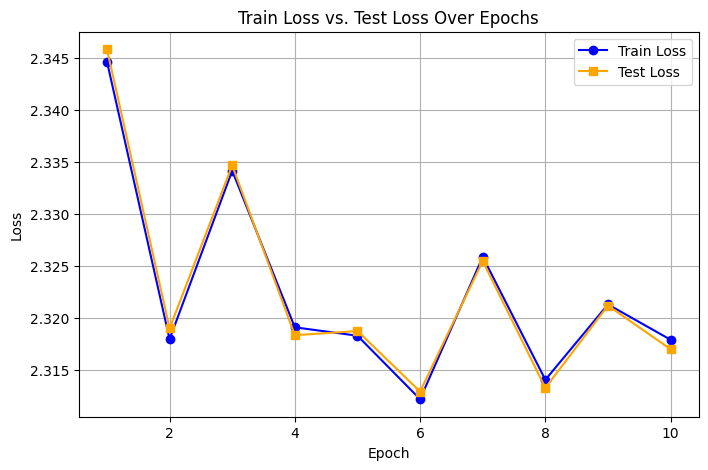

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Train Loss", marker='o', color='blue')
plt.plot(range(1, epochs + 1), test_losses, label="Test Loss", marker='s', color='orange')

plt.title("Train Loss vs. Test Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()